In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')


In [3]:
dt_model_pre = DecisionTreeClassifier(random_state=20)
dt_model_pre.fit(x_train_pre, y_train_pre)

dt_pred_pre = dt_model_pre.predict(x_test_pre)
dt_prob_pre = dt_model_pre.predict_proba(x_test_pre)[:, 1]
print(dt_prob_pre)

[1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1.
 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0.
 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0.
 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1.
 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0.
 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1.
 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0.

In [4]:
dt_accuracy_pre = accuracy_score(y_test_pre, dt_pred_pre)
print("Decision Tree Accuracy (Pre-split SMOTE):", round(dt_accuracy_pre, 4))


Decision Tree Accuracy (Pre-split SMOTE): 0.7953


In [5]:
print("Classification Report\n")
print(classification_report(y_test_pre, dt_pred_pre))

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       339
           1       0.78      0.83      0.80       340

    accuracy                           0.80       679
   macro avg       0.80      0.80      0.80       679
weighted avg       0.80      0.80      0.80       679



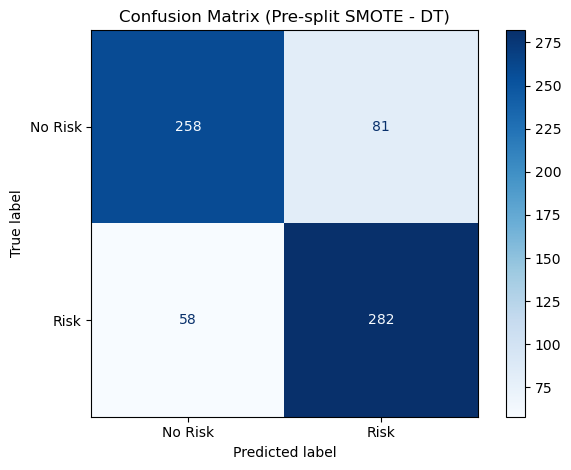

In [6]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, dt_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - DT)")
plt.tight_layout()
plt.show()

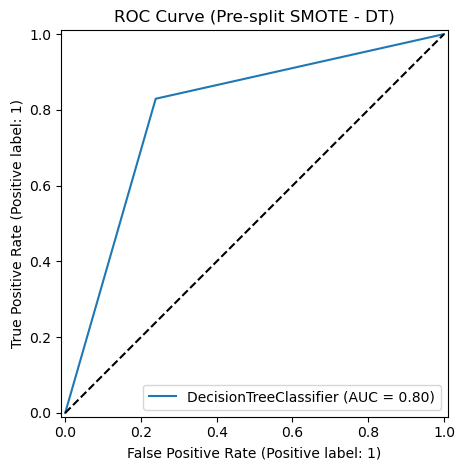

ROC-AUC Score: 0.7952


In [7]:
RocCurveDisplay.from_estimator(dt_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - DT)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, dt_prob_pre).round(4))

In [8]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')  # saved earlier
n_importances = len(dt_model_pre.feature_importances_)

if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature": labels,
    "Importance": dt_model_pre.feature_importances_,
})

feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)

print(feature_importance_pre.to_string(index=False))


 Feature  Importance
       9    0.128528
      13    0.085391
      12    0.075525
       8    0.068671
       7    0.066759
      11    0.061774
      15    0.057442
       0    0.050102
      10    0.049752
      16    0.048980
      18    0.045371
      14    0.044969
       6    0.043953
      24    0.035949
      25    0.021785
      21    0.019281
      17    0.016132
      20    0.015492
      23    0.011301
      19    0.010095
       1    0.008930
       4    0.007738
      27    0.007625
      22    0.007133
       3    0.005387
       2    0.002875
       5    0.002617
      26    0.000444


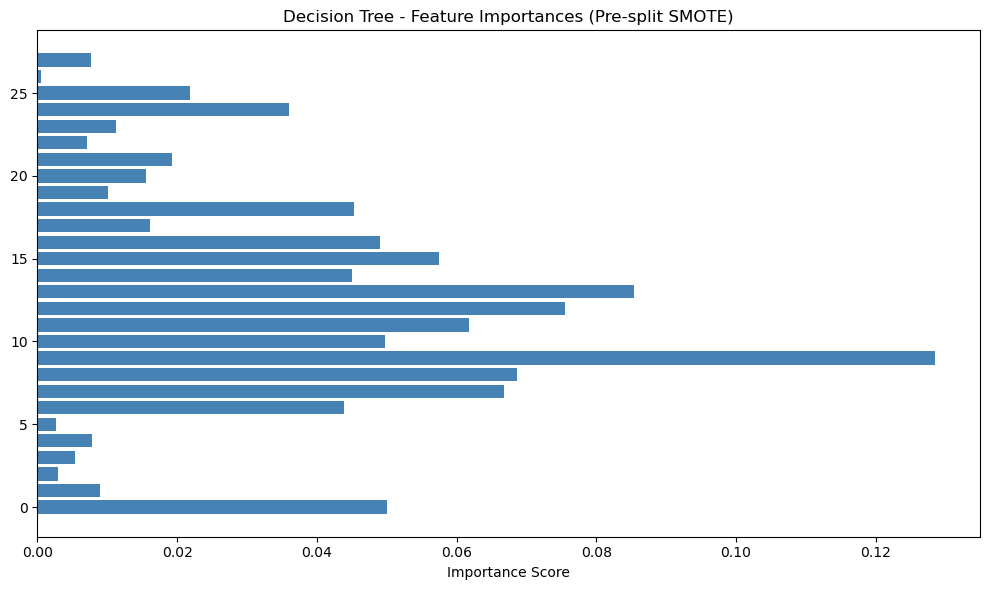

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree - Feature Importances (Pre-split SMOTE)")
plt.tight_layout()
plt.show()

In [10]:
train_pred_pre = dt_model_pre.predict(x_train_pre)
print("Train Accuracy:", round(accuracy_score(y_train_pre, train_pred_pre), 4))
print("Test Accuracy :", round(dt_accuracy_pre, 4))

Train Accuracy: 1.0
Test Accuracy : 0.7953


In [11]:
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search_pre = GridSearchCV(
    DecisionTreeClassifier(random_state=20),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)

print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}


In [12]:
cv_scores_pre = cross_val_score(dt_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

CV ROC-AUC Scores: [0.7404 0.722  0.7753 0.7694 0.7731]
Mean: 0.756 | Std dev: 0.0212


In [13]:
joblib.dump(dt_model_pre, 'decision_tree_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
